In [1]:
# Import all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [2]:
# Load the digits dataset.
digits = load_digits()

x = digits.data
y = digits.target

In [3]:
# Set parameters for grid-search.
param_grid = [{'weights': ['uniform', 'distance'], 'n_neighbors': [1, 2, 3, 4, 5, 10, 15, 20]}]
clf = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, verbose=3, n_jobs=-1)
clf.fit(x, y)
print('Número de Vizinhos mais proximos:', clf.best_params_.get('n_neighbors'))
print('Peso de cada Vizinho dado por: ', clf.best_params_.get('weights'))
print('Precisão do Classificador', clf .best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.5s


Número de Vizinhos mais proximos: 4
Peso de cada Vizinho dado por:  distance
Precisão do Classificador 0.9671742494583719


[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:    2.7s finished


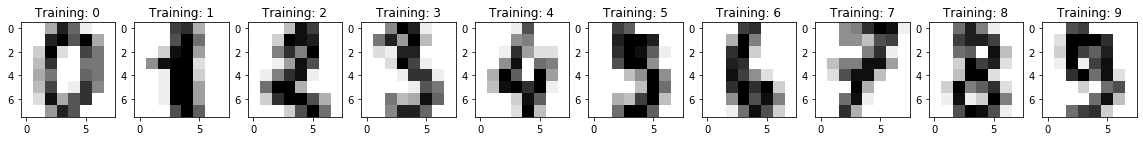

In [4]:
# Plot some digits from the data-set.
plt.figure(figsize=(20, 5))
for i in range(0,10):
    ax = plt.subplot(1, 10, i+1)
    plt.imshow(digits.images[i], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % digits.target[i])
plt.show()

In [5]:
# To apply a classifier on this data, we need to flatten the image, to turn the data in a
# (samples, feature) matrix:

n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Split data into train and test subsets.
x_train, x_test, y_train, y_test = train_test_split(data, y, test_size=0.2, shuffle=False)

acc_train = []
acc_test = []
score_max = 0.9671742494583719
k_max = 4
for k in range(5,80):
    # Create an instance of Neighbours Classifier and fit the data.
    clf = KNeighborsClassifier(k, weights='distance')
    # Train the classifier.
    clf.fit(x_train, y_train)
    # Predict.
    y_pred = clf.predict(x_test)
    # calculate score.
    score_test = clf.score(x_test, y_test)
    acc_test.append(score_test)
    score_train = clf.score(x_train, y_train)
    acc_train.append(score_train)    
    if(score_test > score_max):
        score_max = score_test
        k_max = k

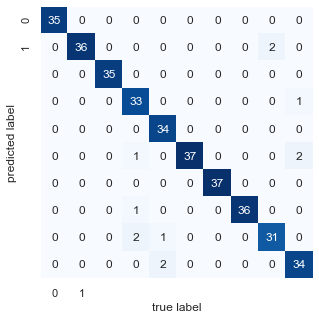

In [7]:
# Create an instance of Neighbours Classifier and fit the data with best k.
clf = KNeighborsClassifier(4, weights='distance')
# Train the classifier.
clf.fit(x_train, y_train)
# Predict.
y_pred = clf.predict(x_test)

# Plot the confusion matrix.
fig = plt.figure(figsize=(5,5))
mat = confusion_matrix(y_test, y_pred)
sns.set()
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=['0','1'], yticklabels=['0','1'], cmap="Blues")
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

In [8]:
# Print classification report.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       0.97      0.89      0.93        37
           4       1.00      0.92      0.96        37
           5       0.93      1.00      0.96        37
           6       1.00      1.00      1.00        37
           7       0.97      1.00      0.99        36
           8       0.91      0.94      0.93        33
           9       0.94      0.92      0.93        37

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [9]:
print('Acurácia do modelo:', accuracy_score(y_test, y_pred)*100)

Acurácia do modelo: 96.66666666666667
